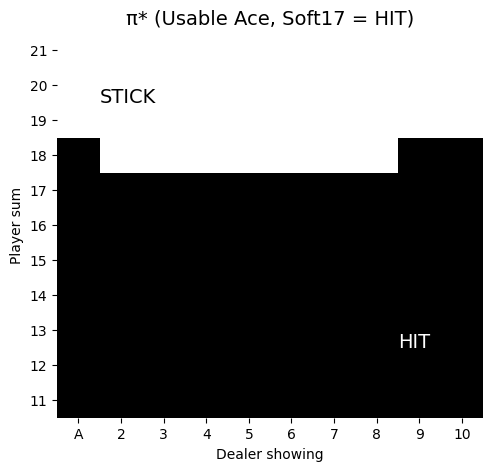

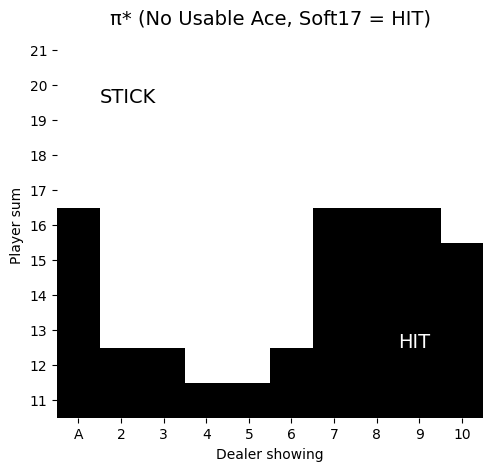

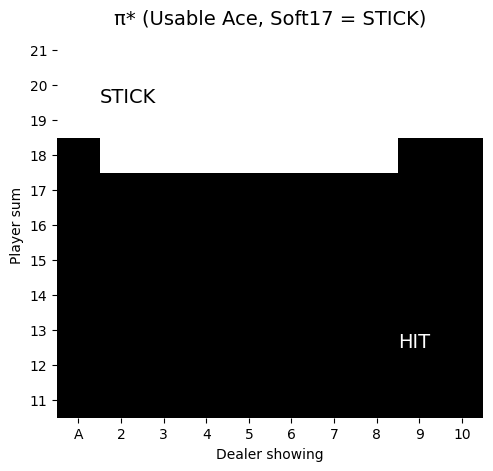

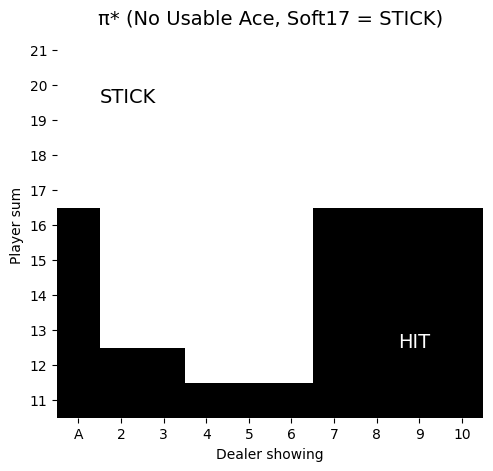

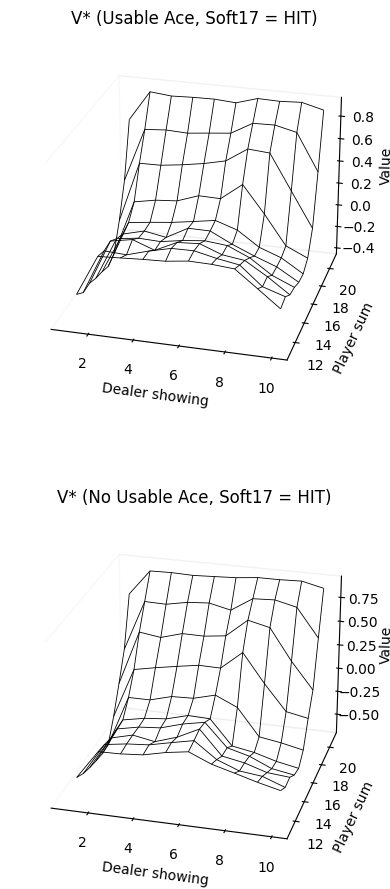

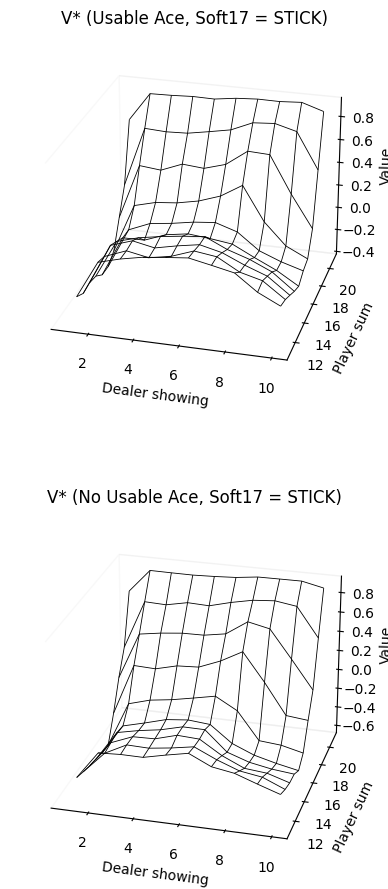

In [48]:
# Environment setup
import numpy as np
import random

action_hit = 0
action_stick = 1
actions = [action_hit, action_stick]

def draw_card():
  card =random.randint(1, 13) #get a random card form 1 to 13
  return min(card, 10) #face cards are treated as 10

def hand_total(hand):
  total = sum(hand) #compute the total card value in hand
  usable_ace = 1 in hand and total + 10 <= 21 #check if Ace is usable
  if usable_ace:
    total += 10
  return total, usable_ace

# Hits on soft 17
def soft17_hit(dealer_hand):
  while True:
    total, usable_ace = hand_total(dealer_hand);

    if total < 17:
      dealer_hand.append(draw_card())
    elif total == 17 and usable_ace:
      dealer_hand.append(draw_card())
    else:
      break
  return dealer_hand

#Sticks on soft 17
def soft17_stick(dealer_hand):
  while True:
    total, usable_ace = hand_total(dealer_hand);

    if total < 17:
      dealer_hand.append(draw_card())
    else:
      break
  return dealer_hand

#Game Reward
def compute_reward(player_hand, dealer_hand):
  player_total, _ = hand_total(player_hand)
  dealer_total, _ = hand_total(dealer_hand)

  if player_total > 21:
    return -1
  elif dealer_total > 21:
    return 1
  elif player_total > dealer_total:
    return 1
  elif player_total < dealer_total:
    return -1
  else:
    return 0

#Single Episode
def start_episode(policy, soft17):
  usable_ace = random.choice([True, False]) #initialize the state at the beginning of each episode
  player_sum = random.randint(12, 21)
  dealer_show = random.randint(1, 10)

  if usable_ace and player_sum >= 12:
    second_card = player_sum - 11
    player_hand = [1, second_card]
  else:
    card1 = random.randint(1, player_sum - 1)
    card2 = player_sum - card1
    player_hand = [card1, card2]

  dealer_hand = [dealer_show, draw_card()] #construct dealer_hand using dealer_show

  action = random.choice(actions) #initialize random action

  episode = [] #create a list to store each episode
  state = (player_sum, dealer_show, usable_ace)
  episode.append((state, action)) #store (s, a)

  while action == action_hit:
    player_hand.append(draw_card())
    total, usable_ace = hand_total(player_hand)
    if total > 21:
      reward = -1
      episode.append((None, reward))
      return episode
    state = (total, dealer_show, usable_ace)
    action = policy.get(state, random.choice(actions))
    episode.append((state, action))

  dealer_hand = soft17(dealer_hand)
  reward = compute_reward(player_hand, dealer_hand)
  episode.append((None, reward))
  return episode

#Monte Carlo Exploring Starts Loop
from collections import defaultdict
import numpy as np
Q = defaultdict(lambda: np.zeros(2))
returns = defaultdict(list)
policy = {}

def MCES(N, soft17):
  global Q, returns, policy
  for _ in range(N): #loop over episodes
    episode = start_episode(policy, soft17)

    sa_pairs = []
    for s, a in episode[:-1]: #except (None, reward)
      sa_pairs.append((s, a))

    final_reward = episode[-1][1] #extract the reward
    visited = set()

    for s, a in sa_pairs: #check first visit
      if (s, a) not in visited:
        visited.add((s, a))
        returns[(s, a)].append(final_reward) #append reward to returns
        Q[s][a] = np.mean(returns[(s, a)]) #update Q by averaging returns
        policy[s] = np.argmax(Q[s]) #update policy greedily
#Run
# Case 1: Dealer hits on soft 17
Q = defaultdict(lambda: np.zeros(2))
returns = defaultdict(list)
policy = {}
MCES(500000, soft17_hit) # 500000 episodes
for dealer_show in range(1, 11):
    for usable_ace in [True, False]:
        policy[(11, dealer_show, usable_ace)] = 0
Q_hit = Q
policy_hit = policy

# Case 2: Dealer sticks on soft 17
Q = defaultdict(lambda: np.zeros(2))
returns = defaultdict(list)
policy = {}
MCES(500000, soft17_stick)
for dealer_show in range(1, 11):
    for usable_ace in [True, False]:
        policy[(11, dealer_show, usable_ace)] = 0
Q_stick = Q
policy_stick = policy

#Policy plot
import matplotlib.pyplot as plt

def plot_policy(policy_dict, usable_ace=True, title="π* (Usable Ace)"):
    grid = np.full((11, 10), np.nan)  # 11 rows for 11–21

    for player_sum in range(11, 22):
        for dealer_show in range(1, 11):
            state = (player_sum, dealer_show, usable_ace)
            if state in policy_dict:
                grid[player_sum - 11, dealer_show - 1] = policy_dict[state]

    fig, ax = plt.subplots(figsize=(5.5, 5))

    x = np.arange(1, 12)   # Dealer 1–11
    y = np.arange(11, 23)  # Player 11–22

    ax.pcolormesh(x, y, grid, cmap='binary_r', shading='flat')

    #HIT (black region), STICK (white region)
    ax.text(9, 13, "HIT", fontsize=14, color='white')
    ax.text(2, 20, "STICK", fontsize=14, color='black')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(np.arange(1.5, 11.5))
    ax.set_xticklabels(['A'] + list(range(2, 11)))
    ax.set_yticks(np.arange(11.5, 22.5))
    ax.set_yticklabels(range(11, 22))
    ax.set_xlim(1, 11)
    ax.set_ylim(11, 22)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=True, bottom=True)

    plt.show()

plot_policy(policy_hit, usable_ace=True, title="π* (Usable Ace, Soft17 = HIT)")
plot_policy(policy_hit, usable_ace=False, title="π* (No Usable Ace, Soft17 = HIT)")
plot_policy(policy_stick, usable_ace=True, title="π* (Usable Ace, Soft17 = STICK)")
plot_policy(policy_stick, usable_ace=False, title="π* (No Usable Ace, Soft17 = STICK)")

#Value Function Plot
def plot_value(Q, title1, usable1, title2, usable2):
    fig = plt.figure(figsize=(11, 11))

    ax1 = fig.add_subplot(211, projection='3d')
    draw_wireframe(ax1, Q, usable_ace=usable1, title=title1)

    ax2 = fig.add_subplot(212, projection='3d')
    draw_wireframe(ax2, Q, usable_ace=usable2, title=title2)

    plt.subplots_adjust(hspace=0.3)
    plt.show()

def draw_wireframe(ax, Q, usable_ace=True, title="V*", elev=25, azim=-75):
    x = np.arange(1, 11)
    y = np.arange(11, 22)
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, np.nan, dtype=float)

    for i, ps in enumerate(y):
        for j, ds in enumerate(x):
            state = (ps, ds, usable_ace)
            if state in Q:
                Z[i, j] = np.max(Q[state])

    ax.plot_wireframe(X, Y, Z, color='black', linewidth=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_zlabel("Value")
    ax.view_init(elev=elev, azim=azim)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)

plot_value(
    Q_hit,
    title1="V* (Usable Ace, Soft17 = HIT)",
    usable1=True,
    title2="V* (No Usable Ace, Soft17 = HIT)",
    usable2=False
)

plot_value(
    Q_stick,
    title1="V* (Usable Ace, Soft17 = STICK)",
    usable1=True,
    title2="V* (No Usable Ace, Soft17 = STICK)",
    usable2=False
)